### Proyecto 5: asistente RAG sobre conocimiento interno

Base de conocimiento ficticia: 5 documentos de politicas internas de "NubeTech" (empresa inventada, `05-rag/conocimiento/`). El LLM no vio estos documentos en su entrenamiento -- le vamos a dar la capacidad de responder preguntas sobre ellos sin reentrenarlo, buscando los fragmentos relevantes y pasandoselos como contexto.

Pipeline: documentos -> chunks -> embeddings -> base vectorial (Chroma) -> busqueda por similitud -> prompt con contexto -> respuesta del LLM.

#### Paso 1: cargar y trocear los documentos

Los documentos completos son largos para meterlos enteros en cada busqueda -- los cortamos en "chunks" de ~500 caracteres con superposicion de 50 (para no cortar una idea justo en la mitad y perder contexto en el borde).

In [1]:
import glob
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

rutas = sorted(glob.glob("../conocimiento/*.md"))
documentos_crudos = []
for ruta in rutas:
    with open(ruta, encoding="utf-8") as f:
        documentos_crudos.append(Document(page_content=f.read(), metadata={"fuente": ruta.split("/")[-1]}))

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(documentos_crudos)

print(f"{len(documentos_crudos)} documentos -> {len(chunks)} chunks")
print(f"Ejemplo: [{chunks[0].metadata['fuente']}] {chunks[0].page_content[:100]}...")

5 documentos -> 11 chunks
Ejemplo: [beneficios.md] # Beneficios — NubeTech...


#### Paso 2: embeddings + base vectorial

`gemini-embedding-001` de Google convierte cada chunk en un vector (el modelo viejo `text-embedding-004` no esta disponible para cuentas nuevas, mismo problema que con `gemini-2.5-flash` en semana 1). Chroma los guarda y sabe buscar los K vectores mas cercanos a una consulta dada.

In [2]:
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
import os

load_dotenv()
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001", google_api_key=os.getenv("GOOGLE_API_KEY"))

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="nubetech-conocimiento",
)
print(f"Vectorstore con {vectorstore._collection.count()} vectores")

Vectorstore con 11 vectores


#### Paso 3: RAG completo -- retrieval + generacion

Buscamos los 3 chunks mas relevantes a la pregunta, los metemos en el prompt como contexto, y le pedimos a Gemini que responda SOLO en base a eso (para que no invente politicas que no existen en los documentos).

In [3]:
from google import genai

cliente = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

def preguntar(pregunta, k=3):
    resultados = vectorstore.similarity_search(pregunta, k=k)
    contexto = "\n\n".join(f"[{r.metadata['fuente']}]\n{r.page_content}" for r in resultados)

    prompt = f"""Sos el asistente interno de NubeTech. Respondé la pregunta usando UNICAMENTE la informacion del contexto de abajo. Si el contexto no alcanza para responder, decilo -- no inventes.

Contexto:
{contexto}

Pregunta: {pregunta}"""

    respuesta = cliente.models.generate_content(model="gemini-flash-lite-latest", contents=prompt)
    return respuesta.text, [r.metadata["fuente"] for r in resultados]

In [4]:
preguntas = [
    "¿Cuántos días de vacaciones tengo por año?",
    "¿Puedo trabajar remoto todos los días?",
    "¿Qué pasa si sospecho un email de phishing?",
    "¿Cuál es la política de vacaciones en la luna?",
]

for p in preguntas:
    respuesta, fuentes = preguntar(p)
    print(f"P: {p}")
    print(f"R: {respuesta}")
    print(f"Fuentes usadas: {fuentes}")
    print()

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


P: ¿Cuántos días de vacaciones tengo por año?
R: Todo empleado con más de 6 meses de antigüedad tiene derecho a 15 días hábiles de vacaciones por año calendario.
Fuentes usadas: ['politica_vacaciones.md', 'beneficios.md', 'beneficios.md']

P: ¿Puedo trabajar remoto todos los días?
R: Sí, podés trabajar 100% remoto únicamente si sos parte del equipo de infraestructura y soporte 24/7, y contás con la previa aprobación de tu lead. De lo contrario, NubeTech opera bajo modalidad híbrida por defecto.
Fuentes usadas: ['politica_home_office.md', 'beneficios.md', 'beneficios.md']

P: ¿Qué pasa si sospecho un email de phishing?
R: Ante sospecha de phishing, debés reenviar el correo a seguridad@nubetech.com sin hacer click en ningún link, y reportarlo en el canal de Slack #seguridad.
Fuentes usadas: ['seguridad_informatica.md', 'seguridad_informatica.md', 'beneficios.md']

P: ¿Cuál es la política de vacaciones en la luna?
R: El contexto provisto no alcanza para responder la pregunta.
Fuentes usad

#### Paso 4: visualizar los embeddings con t-SNE (3D)

Cada chunk vive en un vector de 768 dimensiones -- imposible de graficar. t-SNE lo comprime a 3D preservando cercania relativa. Si el embedding capturo bien el tema, los chunks del mismo documento deberian agruparse.

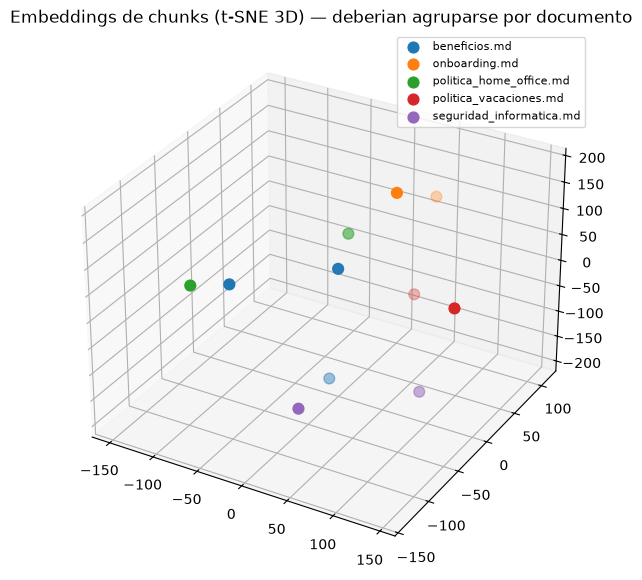

In [5]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

datos = vectorstore.get(include=["embeddings", "metadatas"])
vectores = np.array(datos["embeddings"])
fuentes = [m["fuente"] for m in datos["metadatas"]]

tsne = TSNE(n_components=3, perplexity=min(5, len(vectores) - 1), random_state=42)
puntos_3d = tsne.fit_transform(vectores)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection="3d")
for fuente_unica in sorted(set(fuentes)):
    idx = [i for i, f in enumerate(fuentes) if f == fuente_unica]
    ax.scatter(puntos_3d[idx, 0], puntos_3d[idx, 1], puntos_3d[idx, 2], label=fuente_unica, s=60)
ax.legend(fontsize=8)
ax.set_title("Embeddings de chunks (t-SNE 3D) — deberian agruparse por documento")
plt.show()